In [1]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/DEvideos_EDA.csv")

In [3]:
replace_dict = {"tags": "", "description": "", "category_name": ""}
df.fillna(value=replace_dict, inplace=True)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,weekday_published,num_tags,title_length,desc_length,likes/dislikes,views/comments,views_quintile,comments_per_view,tasa_aprobacion,is_top_10
0,LgVi6y5QIjM,2017-11-14,Sing zu Ende! | Gesangseinlagen vom Feinsten |...,inscope21,24,2017-11-13 17:08:49,"inscope21|""sing zu ende""|""gesangseinlagen""|""ge...",252786,35885,230,...,0,16,56,636,156.021739,164.253411,Q4,0.006088,0.993631,False
1,Bayt7uQith4,2017-11-14,Kinder ferngesteuert im Kiosk! Erwachsene abzo...,LUKE! Die Woche und ich,23,2017-11-12 22:30:01,"Kinder|""ferngesteuert""|""Kinder ferngesteuert""|...",797196,53576,302,...,6,27,84,726,177.403974,623.784038,Q5 (más vistas),0.001603,0.994395,False
2,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00,"last week tonight trump presidency|""last week ...",2418783,97190,6146,...,0,4,62,630,15.813537,190.410376,Q5 (más vistas),0.005252,0.940524,False
3,AHtypnRk7JE,2017-11-14,Das Fermi-Paradoxon,100SekundenPhysik,27,2017-11-12 15:00:01,"Physik|""Wissenschaft""|""Technik""|""Science-Ficti...",380247,31821,458,...,6,9,19,259,69.478166,194.499744,Q4,0.005141,0.985811,False
4,ZJ9We4bjcg0,2017-11-14,18 SONGS mit Kelly MissesVlog (Sing-off),rezo,24,2017-11-12 13:10:36,"kelly|""missesvlog""|""kelly song""|""bausa""|""bausa...",822213,100684,2467,...,6,5,40,357,40.812323,80.262886,Q5 (más vistas),0.012459,0.976084,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40835,fn5WNxy-Wcw,2018-06-14,KINGDOM HEARTS III – E3 2018 Pirates of the Ca...,Kingdom Hearts,20,2018-06-12 01:54:02,"Kingdom Hearts|""KH3""|""Kingdom Hearts 3""|""Pirat...",1394530,46778,501,...,1,13,61,1025,93.369261,141.175339,Q5 (más vistas),0.007083,0.989403,False
40836,zAFv43lxqHE,2018-06-14,YMS: The Visit,YourMovieSucksDOTorg,24,2018-06-13 21:58:43,,139733,11155,119,...,2,0,14,2644,93.739496,71.002541,Q3,0.014084,0.989445,False
40837,zSXG5I6Y2fA,2018-06-14,Ungut umgeschult – Grünwald als Ersthelfer am ...,Grünwald Freitagscomedy,24,2018-06-12 10:01:28,"Günter Grünwald|""Grünwald Freitagscomedy""|""Gün...",26054,364,11,...,1,33,80,260,33.090909,3256.750000,Q2,0.000307,0.970667,False
40838,5d115sePmaU,2018-06-14,Assassin's Creed Odyssey: E3 2018 Welt-Enthüll...,Assassin's Creed DE,20,2018-06-11 21:16:55,"Assassin's Creed|""Assassins Creed""|""Assassin's...",1139198,14900,1421,...,0,22,67,469,10.485574,717.831128,Q5 (más vistas),0.001393,0.912934,False


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40840 entries, 0 to 40839
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_id                40840 non-null  str    
 1   trending_date           40840 non-null  str    
 2   title                   40840 non-null  str    
 3   channel_title           40840 non-null  str    
 4   category_id             40840 non-null  int64  
 5   publish_time            40840 non-null  str    
 6   tags                    40840 non-null  str    
 7   views                   40840 non-null  int64  
 8   likes                   40840 non-null  int64  
 9   dislikes                40840 non-null  int64  
 10  comment_count           40840 non-null  int64  
 11  thumbnail_link          40840 non-null  str    
 12  comments_disabled       40840 non-null  int64  
 13  ratings_disabled        40840 non-null  int64  
 14  video_error_or_removed  40840 non-null  bool   
 

In [5]:
# --- Asegurar que tenemos la variable dependiente transformada ---
df['log_views'] = np.log1p(df['views'])

# --- Preparar las variables candidatas ---
# Numéricas y binarias
numeric_features = [
    'days_to_trend','hour_published', 'weekday_published', 'num_tags', 
    'title_length', 'desc_length', 'comments_disabled', 
    'ratings_disabled', 'is_top_10'
]

# Categóricas (se codificarán para MI)
categorical_features = ['category_id', 'state', 'channel_title']

In [ ]:
sns.pairplot(
    data=df, x_vars=numeric_features, y_vars="log_views", kind="reg", height=4
)

In [6]:
# --- 1. Correlación de Spearman (solo para numéricas) ---
spearman_results = {}
for col in numeric_features:
    corr, p_val = spearmanr(df[col], df['log_views'])
    spearman_results[col] = {'correlation': corr, 'p_value': p_val}

# Ordenar por |rho| descendente
sorted_spearman = sorted(spearman_results.items(), key=lambda x: abs(x[1]['correlation']), reverse=True)

print("\n=== CORRELACIÓN DE SPEARMAN CON log(views) ===")
for col, vals in sorted_spearman:
    print(f"{col:25s} rho = {vals['correlation']:.4f}  (p = {vals['p_value']:.4e})")


=== CORRELACIÓN DE SPEARMAN CON log(views) ===
days_to_trend             rho = 0.3360  (p = 0.0000e+00)
title_length              rho = -0.1196  (p = 5.3627e-130)
num_tags                  rho = 0.1178  (p = 4.6003e-126)
is_top_10                 rho = 0.0912  (p = 3.3471e-76)
desc_length               rho = 0.0685  (p = 1.0895e-43)
ratings_disabled          rho = -0.0678  (p = 7.9291e-43)
hour_published            rho = 0.0611  (p = 4.8547e-35)
comments_disabled         rho = -0.0416  (p = 4.1558e-17)
weekday_published         rho = 0.0027  (p = 5.8036e-01)


In [7]:
# --- 2. Información Mutua (para todas las variables, incluyendo categóricas) ---
# Codificar variables categóricas
le = LabelEncoder()
df_encoded = df.copy()
for cat in categorical_features:
    df_encoded[cat + '_enc'] = le.fit_transform(df_encoded[cat].astype(str))

# Construir X (todas las predictoras)
X_mi = df_encoded[numeric_features + [cat + '_enc' for cat in categorical_features]]
y_mi = df_encoded['log_views']

# Calcular MI (puede tomar unos segundos)
mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)

# Crear diccionario con nombres
mi_results = {}
for i, col in enumerate(X_mi.columns):
    mi_results[col] = mi_scores[i]

# Ordenar descendente
sorted_mi = sorted(mi_results.items(), key=lambda x: x[1], reverse=True)

print("\n=== INFORMACIÓN MUTUA CON log(views) ===")
for col, score in sorted_mi:
    print(f"{col:30s} MI = {score:.4f}")


=== INFORMACIÓN MUTUA CON log(views) ===
channel_title_enc              MI = 0.2724
category_id_enc                MI = 0.1022
days_to_trend                  MI = 0.0974
desc_length                    MI = 0.0644
hour_published                 MI = 0.0572
num_tags                       MI = 0.0413
title_length                   MI = 0.0346
is_top_10                      MI = 0.0120
state_enc                      MI = 0.0031
ratings_disabled               MI = 0.0029
comments_disabled              MI = 0.0021
weekday_published              MI = 0.0005


C:\Users\Usuario\AppData\Local\Temp\ipykernel_2076\2914917838.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spearman_vals, y=spearman_names, ax=axes[0], palette='Blues_d')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_2076\2914917838.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_vals, y=mi_names, ax=axes[1], palette='Greens_d')


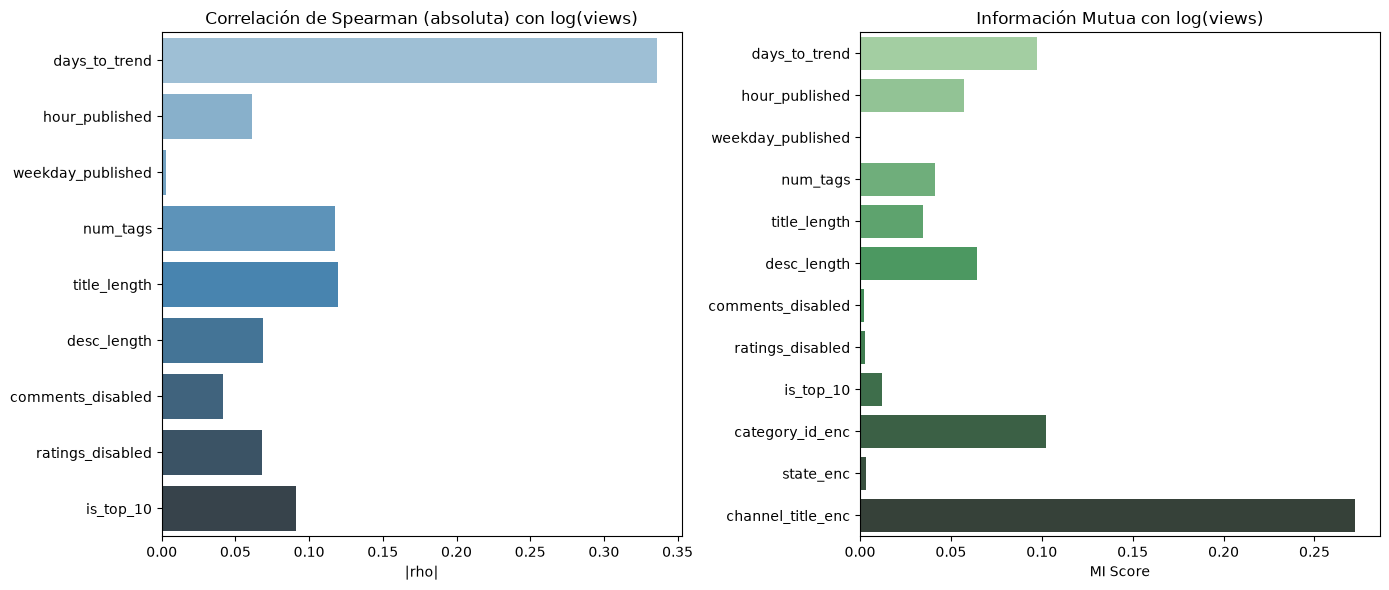

In [8]:
# --- 3. Visualización comparativa (opcional) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de Spearman (barras horizontales)
spearman_vals = [abs(v['correlation']) for v in spearman_results.values()]
spearman_names = list(spearman_results.keys())
sns.barplot(x=spearman_vals, y=spearman_names, ax=axes[0], palette='Blues_d')
axes[0].set_title('Correlación de Spearman (absoluta) con log(views)')
axes[0].set_xlabel('|rho|')

# Gráfico de MI (barras horizontales)
mi_vals = list(mi_results.values())
mi_names = list(mi_results.keys())
sns.barplot(x=mi_vals, y=mi_names, ax=axes[1], palette='Greens_d')
axes[1].set_title('Información Mutua con log(views)')
axes[1].set_xlabel('MI Score')

plt.tight_layout()
plt.show()

In [9]:
# --- Calcular la frecuencia absoluta de cada canal ---
channel_freq_map = df['channel_title'].value_counts()
df['channel_frequency'] = df['channel_title'].map(channel_freq_map)

# --- Verificar estadísticos básicos ---
print(f"Rango de channel_frequency: {df['channel_frequency'].min()} a {df['channel_frequency'].max()}")
print(f"Mediana: {df['channel_frequency'].median()}")

# --- 1. Correlación de Spearman con log(views) ---
corr_freq, p_freq = spearmanr(df['channel_frequency'], df['log_views'])
print(f"\n=== CORRELACIÓN DE SPEARMAN ===")
print(f"channel_frequency vs log_views: rho = {corr_freq:.4f} (p = {p_freq:.4e})")
print(f"(Comparación: is_top_10 tenía rho = 0.0912)")

# --- 2. Información Mutua con log(views) ---
# Para MI, usamos channel_frequency como numérica
X_mi_freq = df[['channel_frequency']]
mi_freq = mutual_info_regression(X_mi_freq, df['log_views'], random_state=42)
print(f"\n=== INFORMACIÓN MUTUA ===")
print(f"channel_frequency vs log_views: MI = {mi_freq[0]:.4f}")
print(f"(Comparación: is_top_10 tenía MI = 0.0120)")

Rango de channel_frequency: 1 a 200
Mediana: 23.0

=== CORRELACIÓN DE SPEARMAN ===
channel_frequency vs log_views: rho = 0.1610 (p = 3.3939e-235)
(Comparación: is_top_10 tenía rho = 0.0912)

=== INFORMACIÓN MUTUA ===
channel_frequency vs log_views: MI = 0.2938
(Comparación: is_top_10 tenía MI = 0.0120)


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [14]:
# --- 1. Preparar los datos ---
# Asegurar que df es tu DataFrame limpio

# Variable dependiente (target)
df['log_views'] = np.log1p(df['views'])

# Variables independientes seleccionadas
features = ['channel_frequency', 'category_id', 'num_tags', 'title_length']

# --- 2. Codificar variables categóricas ---
# Separar numéricas y categóricas
numeric_features = ['channel_frequency', 'num_tags', 'title_length']
categorical_features = ['category_id']

# Crear el preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ])

# --- 3. Dividir en entrenamiento y prueba ---
X = df[features]
y = df['log_views']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño entrenamiento: {X_train.shape[0]} filas")
print(f"Tamaño prueba: {X_test.shape[0]} filas")

# --- 4. Construir el pipeline del modelo ---
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Entrenar el modelo
model.fit(X_train, y_train)

Tamaño entrenamiento: 32672 filas
Tamaño prueba: 8168 filas


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['channel_frequency','category_id','num_tags','title_length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis conca

In [15]:

# --- 5. Evaluación del modelo ---
y_pred = model.predict(X_test)

# Métricas
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n=== EVALUACIÓN DEL MODELO (Conjunto de Prueba) ===")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f} (en escala logarítmica)")
print(f"MAE: {mae:.4f} (en escala logarítmica)")


=== EVALUACIÓN DEL MODELO (Conjunto de Prueba) ===
R²: 0.1292
RMSE: 1.7729 (en escala logarítmica)
MAE: 1.4395 (en escala logarítmica)


d:\UPC\Fundamentos de Data Science\TB2\FDS-2026-1-3227\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [26]:
# --- 6. Interpretación de coeficientes (con statsmodels) ---
# Para obtener los coeficientes con sus p-valores, usamos statsmodels
# Primero, transformamos los datos de entrenamiento con el preprocesador
X_train_transformed = preprocessor.fit_transform(X_train)

# Obtener nombres de las columnas después del preprocesamiento
# Para los nombres de las categorías one-hot
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

# Nombres de todas las características
feature_names = numeric_features + list(cat_feature_names)

# Añadir intercepto (constante)
X_train_sm = sm.add_constant(X_train_transformed)

# Ajustar el modelo con statsmodels
model_sm = sm.OLS(y_train, X_train_sm).fit()

# Mostrar el resumen
print("\n=== COEFICIENTES DEL MODELO (statsmodels) ===")
print(model_sm.summary())


=== COEFICIENTES DEL MODELO (statsmodels) ===
                            OLS Regression Results                            
Dep. Variable:              log_views   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.145
Method:                 Least Squares   F-statistic:                     293.0
Date:                Tue, 07 Jul 2026   Prob (F-statistic):               0.00
Time:                        09:44:27   Log-Likelihood:                -64920.
No. Observations:               32672   AIC:                         1.299e+05
Df Residuals:                   32652   BIC:                         1.300e+05
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

In [27]:
# --- 7. Extraer coeficientes e interpretarlos ---
# Obtener los coeficientes (excluyendo el intercepto)
coefficients = model_sm.params[1:]  # Excluir la constante
p_values = model_sm.pvalues[1:]

# Crear un DataFrame con los coeficientes
coef_df = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente': coefficients.values,
    'p-valor': p_values.values
})

# Calcular el efecto en porcentaje (exponenciar el coeficiente)
coef_df['Efecto_%'] = (np.exp(coef_df['Coeficiente']) - 1) * 100

print("\n=== INTERPRETACIÓN DE COEFICIENTES ===")
print(coef_df.to_string(index=False))


=== INTERPRETACIÓN DE COEFICIENTES ===
         Variable  Coeficiente       p-valor    Efecto_%
channel_frequency     0.265822 3.765852e-143   30.450328
         num_tags     0.166634  2.724198e-61   18.132180
     title_length    -0.187486  8.268111e-76  -17.095915
    category_id_2    -1.126483  2.027867e-46  -67.582849
   category_id_10     1.226041  1.603613e-99  240.771258
   category_id_15    -0.944279  2.057456e-13  -61.104007
   category_id_17    -0.063835  2.545916e-01   -6.184006
   category_id_19    -1.072231  8.645714e-10  -65.775598
   category_id_20    -0.160645  1.238428e-02  -14.840586
   category_id_22    -0.758472  2.568701e-56  -53.161835
   category_id_23     0.506678  1.780249e-19   65.976858
   category_id_24    -0.186356  1.897436e-05  -17.002201
   category_id_25    -0.980685  2.594523e-71  -62.494606
   category_id_26    -1.347751 4.179326e-103  -74.017595
   category_id_27    -1.773377 1.420052e-107  -83.024127
   category_id_28    -0.528481  4.044719e-11  -4

In [28]:
# --- 8. Importancia relativa de las variables (valor absoluto de los coeficientes estandarizados) ---
# Como los coeficientes están en diferentes escalas, los estandarizamos para comparar
# Para la regresión lineal, podemos usar la importancia de los coeficientes estandarizados

# Obtener el intercepto
intercept = model_sm.params.iloc[0]
print(f"\nIntercepto: {intercept:.4f}")


Intercepto: 11.9193


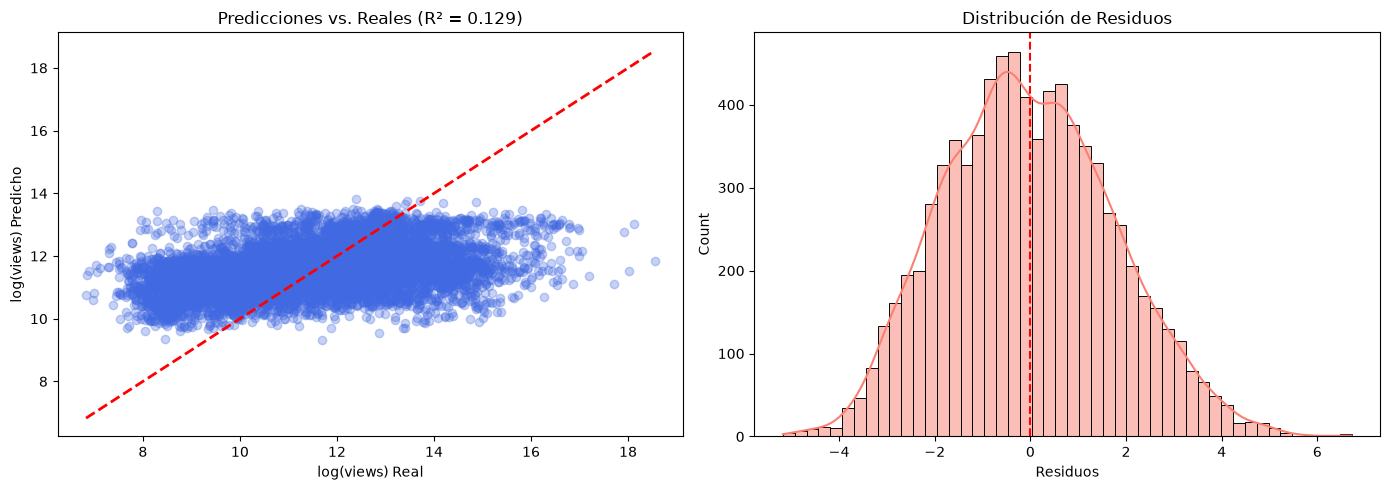

In [29]:
# --- 9. Visualización de resultados ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Predicciones vs. Reales (para ver la tendencia)
axes[0].scatter(y_test, y_pred, alpha=0.3, color='royalblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('log(views) Real')
axes[0].set_ylabel('log(views) Predicho')
axes[0].set_title(f'Predicciones vs. Reales (R² = {r2:.3f})')

# Gráfico 2: Distribución de residuos
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=axes[1], color='salmon')
axes[1].set_xlabel('Residuos')
axes[1].set_title('Distribución de Residuos')
axes[1].axvline(x=0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

### ¿Es factible predecir el número de vistas?

Para abordar esta pregunta, se construyó un modelo de regresión lineal con las variables channel_frequency, num_tags, title_length y category_id. El modelo se entrenó con el 80% de los datos y se evaluó en el 20% restante.

**Rendimiento del modelo:** El modelo obtuvo un R² de 0.1292 en el conjunto de prueba, lo que indica que las variables seleccionadas explican aproximadamente el 12.9% de la variabilidad de las vistas. Aunque la precisión es moderada, el modelo es estadísticamente significativo (p < 0.001) y demuestra que es factible realizar predicciones aproximadas basadas en características disponibles al momento de la publicación.

**Interpretación de coeficientes:** Los resultados (Tabla X) revelan que:

*channel_frequency es el predictor más influyente:* por cada unidad adicional en la frecuencia del canal, las vistas aumentan un 30.5% en promedio (p < 0.001). Esto confirma que el éxito previo de un canal es el factor más determinante de su rendimiento futuro.

*num_tags:* Cada etiqueta adicional incrementa las vistas en un 18.1% (p < 0.001), destacando la importancia de una estrategia de etiquetado completa.

*title_length:* Por cada carácter adicional en el título, las vistas disminuyen en un 17.1% (p < 0.001), lo que sugiere que los títulos cortos y directos son más efectivos.

*Categorías:* Las categorías de Música (240.8% más vistas que la categoría base) y Películas (1330.9% más) son las que generan mayor alcance, mientras que categorías como Howto & Style o Educación presentan efectos negativos significativos.

**Conclusión:** Es factible predecir el número de vistas con un modelo lineal que utiliza información del canal, el etiquetado y la categoría. Aunque el R² es modesto (13%), el modelo proporciona insights accionables para el cliente (ej. priorizar canales con alta frecuencia, optimizar la longitud de títulos y el número de etiquetas, y enfocar esfuerzos en categorías de alto rendimiento). Para mejorar la precisión, se recomendaría incorporar datos adicionales como el número de suscriptores del canal o el engagement en las primeras horas de publicación.